In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
import napari

SMOOTH_SIGMA = 5
AUC_BINS = 16


def smooth_paramap(data, seg, sigma=SMOOTH_SIGMA):
    filled = np.where((seg > 0) & np.isfinite(data), data, 0.0)
    smoothed = uniform_filter(filled, size=sigma)
    smoothed[seg == 0] = np.nan
    return smoothed


def to_label_layer(data, seg, n_bins=None):
    valid = data[seg > 0]
    valid = valid[~np.isnan(valid)]
    vmin = float(np.percentile(valid, 1))
    vmax = float(np.percentile(valid, 99))

    out = np.zeros_like(data, dtype=np.int32)
    mask = (seg > 0) & np.isfinite(data)

    if n_bins is not None:
        bins = np.linspace(vmin, vmax, n_bins + 1)
        out[mask] = np.digitize(data[mask], bins)
    else:
        out[mask] = np.round(data[mask]).astype(np.int32)

    out[~mask] = 0
    return out


def ordered_label_colors(label_array, cmap_name='plasma'):
    """Assign sequential colors to labels in sorted order — no cycling."""
    labels = np.sort(np.unique(label_array))
    labels = labels[labels != 0]
    n = len(labels)
    base = plt.get_cmap(cmap_name)
    color_dict = {0: [0, 0, 0, 0]}
    for i, lbl in enumerate(labels):
        color_dict[int(lbl)] = list(base(i / max(n - 1, 1)))
    return color_dict


pe  = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v1/whole_paramap/PE_full_TIC_numerical.npy')
t0  = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v1/whole_paramap/T0_full_TIC_numerical.npy')
tp  = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v1/whole_paramap/TP_full_TIC_numerical.npy')
auc = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v1/whole_paramap/AUC_full_TIC_numerical.npy')
seg = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v1/whole_paramap/segmentation.npy')
im  = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v1/whole_paramap/image.npy')

pe_s  = smooth_paramap(pe,  seg)
t0_s  = smooth_paramap(t0,  seg)
tp_s  = smooth_paramap(tp,  seg)
auc_s = smooth_paramap(auc, seg)

pe_labels  = to_label_layer(pe_s,  seg)
t0_labels  = to_label_layer(t0_s,  seg)
tp_labels  = to_label_layer(tp_s,  seg)
auc_labels = to_label_layer(auc_s, seg, AUC_BINS)

viewer = napari.Viewer()
viewer.add_image(im[..., 20], name='B-mode', colormap='gray')

pe_layer  = viewer.add_labels(pe_labels,  name='PE',  opacity=0.7, visible=True)
t0_layer  = viewer.add_labels(t0_labels,  name='T0',  opacity=0.7, visible=False)
tp_layer  = viewer.add_labels(tp_labels,  name='TP',  opacity=0.7, visible=False)
auc_layer = viewer.add_labels(auc_labels, name='AUC', opacity=0.7, visible=False)

pe_layer.color  = ordered_label_colors(pe_labels)
t0_layer.color  = ordered_label_colors(t0_labels)
tp_layer.color  = ordered_label_colors(tp_labels)
auc_layer.color = ordered_label_colors(auc_labels)

viewer.add_labels(seg.astype(np.int32), name='VOI', opacity=0.2)
napari.run()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import napari
from napari.utils.colormaps import Colormap

N_BINS = 16


def make_discrete_cmap(data, seg, name, n_bins=N_BINS):
    valid = data[seg > 0]
    valid = valid[~np.isnan(valid)]
    vmin = float(np.percentile(valid, 1))
    vmax = float(np.percentile(valid, 99))

    base = plt.get_cmap('hsv', n_bins)
    colors = np.array([base(i) for i in range(n_bins)])
    colors[0] = [0.0, 0.0, 0.0, 1.0]  # background -> black

    controls = np.linspace(0.0, 1.0, n_bins + 1)
    cmap = Colormap(name=name, colors=colors, controls=controls, interpolation='zero')
    bin_edges = np.linspace(vmin, vmax, n_bins + 1)
    return cmap, vmin, vmax, bin_edges


def show_legend(cmap_info: dict):
    n_maps = len(cmap_info)
    fig, axes = plt.subplots(1, n_maps, figsize=(3 * n_maps, 4))
    if n_maps == 1:
        axes = [axes]

    for ax, (label, (colors, bin_edges, unit, desc)) in zip(axes, cmap_info.items()):
        listed = mcolors.ListedColormap(colors)
        norm = mcolors.BoundaryNorm(bin_edges, listed.N)
        sm = plt.cm.ScalarMappable(cmap=listed, norm=norm)
        sm.set_array([])

        cb = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.8, pad=0.05)
        tick_vals = [bin_edges[0], bin_edges[len(bin_edges) // 2], bin_edges[-1]]
        cb.set_ticks(tick_vals)
        cb.set_ticklabels([f'{v:.1f}' for v in tick_vals])
        cb.set_label(unit, fontsize=9)
        ax.set_title(f'{label}\n({desc})', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


pe  = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v1/whole_paramap/PE_full_TIC_numerical.npy')
t0  = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v1/whole_paramap/T0_full_TIC_numerical.npy')
tp  = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v1/whole_paramap/TP_full_TIC_numerical.npy')
auc = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v1/whole_paramap/AUC_full_TIC_numerical.npy')
seg = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v1/whole_paramap/segmentation.npy')
im  = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v1/whole_paramap/image.npy')

pe_cmap,  pe_min,  pe_max,  pe_edges  = make_discrete_cmap(pe,  seg, 'discrete_pe')
t0_cmap,  t0_min,  t0_max,  t0_edges  = make_discrete_cmap(t0,  seg, 'discrete_t0')
tp_cmap,  tp_min,  tp_max,  tp_edges  = make_discrete_cmap(tp,  seg, 'discrete_tp')
auc_cmap, auc_min, auc_max, auc_edges = make_discrete_cmap(auc, seg, 'discrete_auc')

show_legend({
    'PE':  (pe_cmap.colors,  pe_edges,  'a.u.',   'peak enhancement'),
    'T0':  (t0_cmap.colors,  t0_edges,  'frames', 'contrast arrival frame'),
    'TP':  (tp_cmap.colors,  tp_edges,  'frames', 'frame of peak enhancement'),
    'AUC': (auc_cmap.colors, auc_edges, 'a.u.',   'area under curve'),
})

pe_display  = np.where(np.isnan(pe),  0, pe)
t0_display  = np.where(np.isnan(t0),  0, t0)
tp_display  = np.where(np.isnan(tp),  0, tp)
auc_display = np.where(np.isnan(auc), 0, auc)

viewer = napari.Viewer()
viewer.add_image(im[..., 20], name='B-mode', colormap='gray')
viewer.add_image(pe_display,  name='PE',  colormap=pe_cmap,
                 contrast_limits=(pe_min,  pe_max),  opacity=0.7, visible=True)
viewer.add_image(t0_display,  name='T0',  colormap=t0_cmap,
                 contrast_limits=(t0_min,  t0_max),  opacity=0.7, visible=False)
viewer.add_image(tp_display,  name='TP',  colormap=tp_cmap,
                 contrast_limits=(tp_min,  tp_max),  opacity=0.7, visible=False)
viewer.add_image(auc_display, name='AUC', colormap=auc_cmap,
                 contrast_limits=(auc_min, auc_max), opacity=0.7, visible=False)
viewer.add_labels(seg.astype(np.int32), name='VOI', opacity=0.2)
napari.run()


Best slice: 18, with 16864 valid pixels


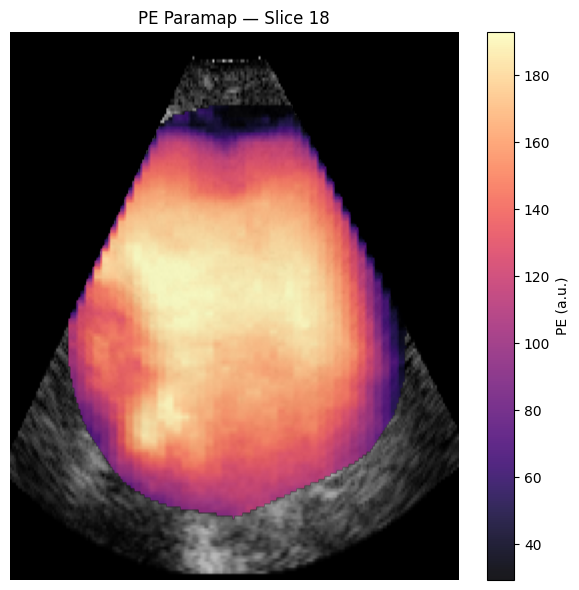

In [9]:
import numpy as np
import matplotlib.pyplot as plt

pe  = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v2/whole_paramap/PE_full_TIC_numerical.npy')
seg = np.load('//Users/samantha/Desktop/tul/china data/p21/new_v2/whole_paramap/segmentation.npy')
im  = np.load('/Users/samantha/Desktop/tul/china data/p21/new_v2/whole_paramap/image.npy')

# Find best slice automatically
counts = np.array([
    np.sum(np.isfinite(pe[:, :, xi]) & (seg[:, :, xi] > 0))
    for xi in range(pe.shape[2])
])
ax_slice = int(np.argmax(counts))
print(f"Best slice: {ax_slice}, with {counts[ax_slice]} valid pixels")

frame = 100  # B-mode time point

# Mask outside VOI → transparent
pe_slice = pe[:, :, ax_slice].astype(float)
pe_slice[seg[:, :, ax_slice] == 0] = np.nan

# Color scale from valid pixels only
valid = pe_slice[np.isfinite(pe_slice)]
vmin, vmax = np.percentile(valid, 1), np.percentile(valid, 99)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(np.rot90(im[:, :, ax_slice, frame], k=3), cmap='gray', aspect='auto')
mappable = ax.imshow(np.rot90(pe_slice, k=3), cmap='magma', alpha=0.9,
                     aspect='auto', vmin=vmin, vmax=vmax)
plt.colorbar(mappable, ax=ax, label='PE (a.u.)')
ax.axis('off')
plt.title(f'PE Paramap — Slice {ax_slice}')
plt.tight_layout()
plt.show()
